In [200]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import DBSCAN, KMeans
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors

df = pd.read_csv("Mall_Customers.csv")
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [201]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
CustomerID,200.0,100.50,57.879185,1.0,50.75,100.5,150.25,200.0
Age,200.0,38.85,13.969007,18.0,28.75,36.0,49.00,70.0
Annual Income (k$),200.0,60.56,26.264721,15.0,41.50,61.5,78.00,137.0
Spending Score (1-100),200.0,50.20,25.823522,1.0,34.75,50.0,73.00,99.0


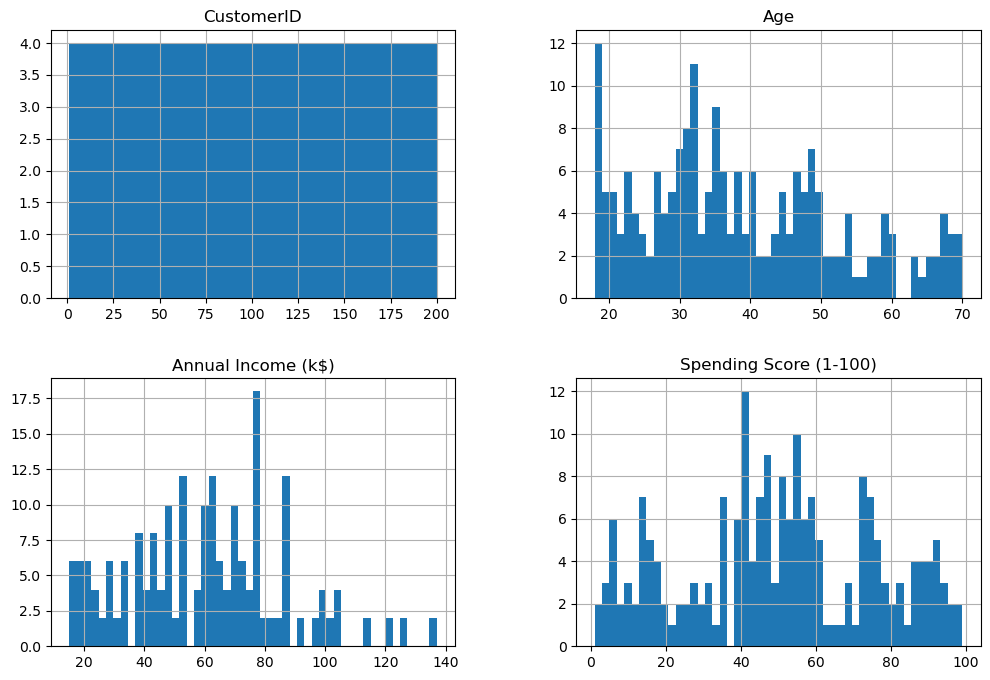

In [202]:
df.hist(bins = 50, figsize = (12, 8))
plt.show()

In [203]:
# Preprocessing
#df.drop(columns=['CustomerID'], inplace = True)
#df['Gender'] = df['Gender'].map({'Male':0, 'Female':1})

df.drop(columns=['CustomerID','Age','Gender'], inplace=True)

scaler = RobustScaler()
df_scaled = scaler.fit_transform(df)

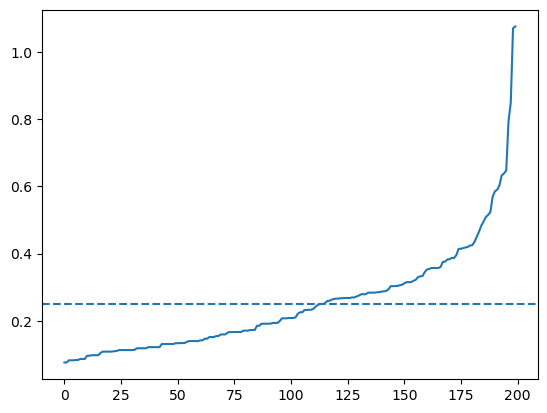

In [204]:
neighbours = NearestNeighbors(n_neighbors=8)
nbrs = neighbours.fit(df_scaled)
dis, ind = nbrs.kneighbors(df_scaled)

dis = np.sort(dis[:,-1])
plt.plot(dis)
plt.axhline(y=0.25, linestyle='--')

In [205]:
for eps in [0.3,0.4,0.5, 0.6,0.7,0.8,1]:
    cluster = DBSCAN(eps = eps, min_samples= 4)
    labels = cluster.fit_predict(df_scaled)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = (labels == -1).sum()
    print(f"eps = {eps}, clusters: {n_clusters}, noise points: {n_noise} ({n_noise/len(labels)*100:.1f}%)")

eps = 0.3, clusters: 2, noise points: 13 (6.5%)
eps = 0.4, clusters: 1, noise points: 7 (3.5%)
eps = 0.5, clusters: 1, noise points: 0 (0.0%)
eps = 0.6, clusters: 1, noise points: 0 (0.0%)
eps = 0.7, clusters: 1, noise points: 0 (0.0%)
eps = 0.8, clusters: 1, noise points: 0 (0.0%)
eps = 1, clusters: 1, noise points: 0 (0.0%)


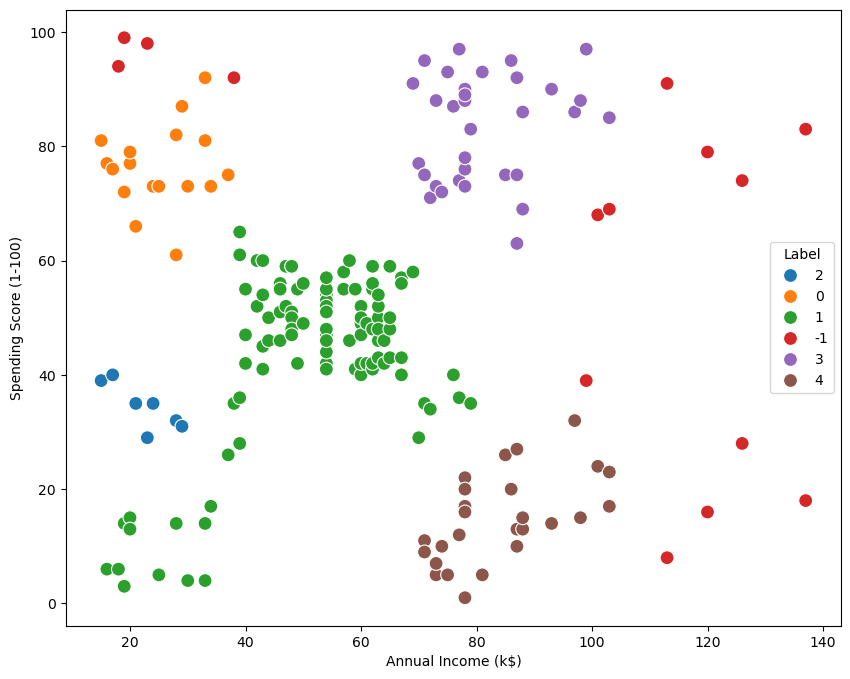

In [213]:
cluster = DBSCAN(eps = 0.25, min_samples=4)
df['Label'] = cluster.fit_predict(df_scaled).astype(str)

plt.figure(figsize = (10,8))
sns.scatterplot(x = 'Annual Income (k$)', y = 'Spending Score (1-100)', data = df, hue = 'Label', palette = 'tab10', s=100)
plt.show()

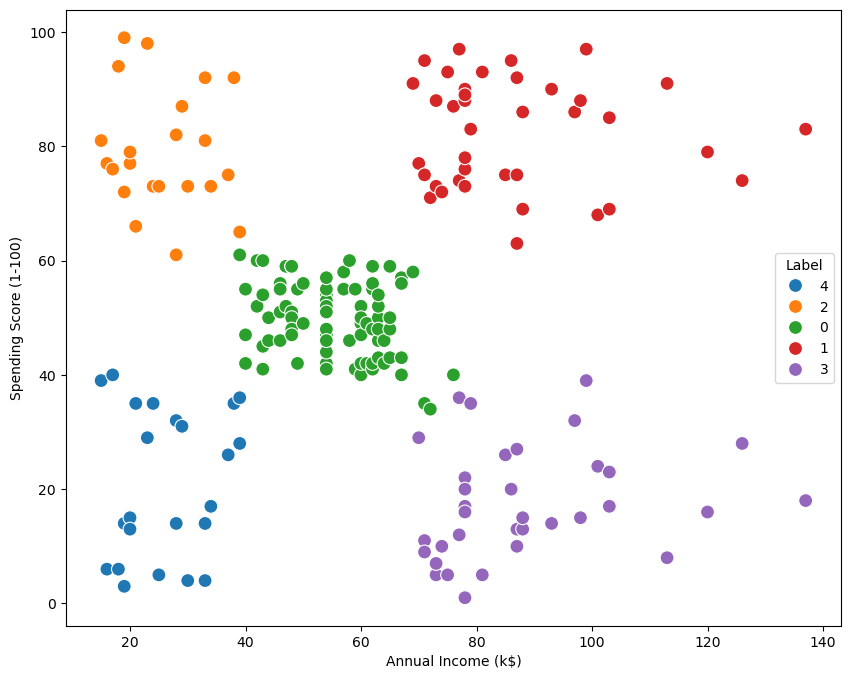

In [207]:
kmeans = KMeans(n_clusters=5, random_state = 42)
df['Label'] = kmeans.fit_predict(df).astype(str)

plt.figure(figsize = (10,8))
sns.scatterplot(x = 'Annual Income (k$)', y = 'Spending Score (1-100)', data = df, hue = 'Label', palette = 'tab10', s=100)
plt.show()
